# 01 · Data understanding

**SkillPath** (IT3051 Fundamentals of Data Mining, group KND_12)

Stage 3, part 1: what is in the file, how it is structured, and which record-level
problems exist before any cohort or feature decisions are made.

Dataset: Stack Overflow Annual Developer Survey 2025, public results
(`survey_results_public.csv`, `survey_results_schema.csv`). Licence: ODbL v1.0.

This notebook only reads the raw file. It does not look at the target in relation
to the features (that happens in `02_eda` on the training split only).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skillpath import config as C
from skillpath import viz
from skillpath.data import load_raw, load_schema
from skillpath.cleaning import answered_count

viz.setup()
pd.set_option("display.max_colwidth", 90)
raw = load_raw()
schema = load_schema()
print(f"rows: {raw.shape[0]:,}   columns: {raw.shape[1]}")

rows: 49,123   columns: 170


## 1. Structure of the file

One row = one survey response, identified by `ResponseId`. The schema file lists
139 question fields; the public CSV has 170 columns because matrix questions are
expanded into several columns (for example `LanguageHaveWorkedWith`,
`LanguageWantToWorkWith`, `LanguageAdmired`) and the AI task matrix into five
level columns.

In [2]:
print("unique ResponseId:", raw[C.ID_COL].is_unique)
print("\nschema question types:")
print(schema["type"].value_counts().rename({"MC": "multiple choice", "TE": "text entry",
                                              "RO": "rank order", "Matrix": "matrix"}).to_string())
print("\npandas dtypes of the 170 columns:")
print(raw.dtypes.astype(str).value_counts().to_string())

unique ResponseId: True

schema question types:
type
rank order         49
multiple choice    48
text entry         29
matrix             13

pandas dtypes of the 170 columns:
str        119
float64     50
int64        1


### Variable types used by SkillPath

Many columns are stored as text but mean very different things. The table below
classifies every column the project uses, because the type decides the encoding
in Stage 4.

In [3]:
multi = [c for c in raw.columns if raw[c].astype(str).str.contains(C.MULTI_SEP, regex=False).any()]
groups = {
    "Target source (single choice, 32 values)": ["DevType"],
    "Technology used / wanted (multi-select)": [c for pair in C.TECH_BLOCKS.values() for c in pair[:2]],
    "Gate questions (Yes/No)": [g for _, _, g in C.TECH_BLOCKS.values() if g],
    "Numeric (whole years)": ["YearsCode", "WorkExp"],
    "Ordinal (ordered answer scale)": list(C.ORDINAL_MAPS),
    "Nominal (unordered categories)": ["Country", "LearnCodeAI", "Industry", "RemoteWork", "ICorPM",
                                       "MainBranch", "Employment", "AIThreat"],
    "AI task matrix (5 multi-select level columns)": list(C.AI_TOOL_COLUMNS),
    "Continuous (USD)": ["ConvertedCompYearly"],
}
rows = []
for g, cols in groups.items():
    for c in cols:
        rows.append({"group": g, "column": c, "n_unique": raw[c].nunique(),
                     "multi_select": c in multi, "% missing (raw)": round(raw[c].isna().mean() * 100, 1)})
var_types = pd.DataFrame(rows)
var_types

,group,column,n_unique,multi_select,% missing (raw)
0,"Target source (single choice, 32 values)",DevType,32,False,11.2
1,Technology used / wanted (multi-select),LanguageHaveWorkedWith,15467,True,35.6
2,Technology used / wanted (multi-select),LanguageWantToWorkWith,13724,True,44.9
3,Technology used / wanted (multi-select),DatabaseHaveWorkedWith,6664,True,48.0
4,Technology used / wanted (multi-select),DatabaseWantToWorkWith,5474,True,59.9
5,Technology used / wanted (multi-select),PlatformHaveWorkedWith,18782,True,50.7
6,Technology used / wanted (multi-select),PlatformWantToWorkWith,13329,True,60.5
7,Technology used / wanted (multi-select),WebframeHaveWorkedWith,7412,True,53.2
8,Technology used / wanted (multi-select),WebframeWantToWorkWith,5726,True,64.1
9,Technology used / wanted (multi-select),DevEnvsHaveWorkedWith,7755,True,47.1


## 2. Row count versus the published figure

Stack Overflow reports 49,009 qualifying responses in its methodology; the public
file has 49,123 rows (114 more). The methodology says responses were qualified on
age, consent and the MainBranch question. The file contains no flag that marks the
114 extra rows, so they cannot be identified directly. The near-empty rule in
section 3 removes a far larger set of incomplete responses, so this small
difference does not affect the modelling cohort. It is recorded here as a known
discrepancy.

In [4]:
print(f"public file: {len(raw):,}   published: 49,009   difference: {len(raw) - 49009:,}")

public file: 49,123   published: 49,009   difference: 114


## 3. Near-empty responses

The number of answered fields per response shows two early stopping points before
the main group, which completes most of the survey (80 to 140 fields):

* **10 or fewer fields**: people who stopped after the screening questions.
* **11 to 20 fields**: people who also answered the work block (DevType, years,
  organisation) and then stopped before the technology section.

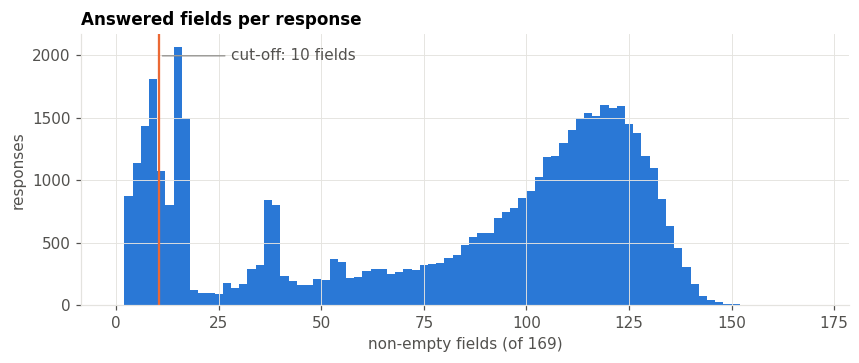

(0, 5]         2006
(5, 10]        3788
(10, 20]       5056
(20, 50]       4029
(50, 80]       4374
(80, 120]     19806
(120, 170]    10064


In [5]:
n_ans = answered_count(raw)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(n_ans, bins=range(0, 172, 2), color=viz.BLUE)
ax.axvline(C.NEAR_EMPTY_MAX_ANSWERED + 0.5, color=viz.ORANGE, lw=1.5)
ax.annotate("cut-off: 10 fields", xy=(C.NEAR_EMPTY_MAX_ANSWERED + 0.5, ax.get_ylim()[1] * 0.92),
            xytext=(28, ax.get_ylim()[1] * 0.92), color=viz.TEXT2, va="center",
            arrowprops=dict(arrowstyle="-", color=viz.MUTED, lw=0.8))
ax.set(title="Answered fields per response", xlabel="non-empty fields (of 169)", ylabel="responses")
ax.grid(axis="y")
viz.save(fig, "01_answered_fields")
plt.show()
print(pd.cut(n_ans, [0, 5, 10, 20, 50, 80, 120, 170]).value_counts().sort_index().to_string())

In [6]:
near_empty = n_ans <= C.NEAR_EMPTY_MAX_ANSWERED
print(f"near-empty responses: {near_empty.sum():,} ({near_empty.mean():.1%})")
print("\nWhat do near-empty responses contain? (share answered)")
print(raw[near_empty].drop(columns=C.ID_COL).notna().mean().sort_values(ascending=False).head(8).round(2).to_string())

second = raw[(n_ans > 10) & (n_ans <= 20)]
print(f"\n11-20 fields: {len(second):,} responses, DevType answered: {second['DevType'].notna().sum():,}, "
      f"technology answered: {second['LanguageHaveWorkedWith'].notna().sum():,}")

near-empty responses: 5,794 (11.8%)

What do near-empty responses contain? (share answered)
MainBranch         1.00
Age                1.00
Employment         0.85
EdLevel            0.84
EmploymentAddl     0.68
LearnCodeChoose    0.61
WorkExp            0.51
LearnCodeAI        0.34

11-20 fields: 5,056 responses, DevType answered: 4,917, technology answered: 16


Near-empty responses only contain the screening block (MainBranch, Age, Employment,
EdLevel). They carry no skills, role or AI information, so they cannot contribute
to any SkillPath component. **Decision: remove responses with 10 or fewer answered
fields** (5,794 rows).

The second stopping group (11 to 20 fields) is kept at this stage because it
contains usable work information, but it almost never reaches the technology
questions, so the recommender cohort rule "answered the main technology question"
removes it later (checked below).

## 4. Duplicate records

In [7]:
dup_any = raw.drop(columns=C.ID_COL).duplicated(keep=False)
dup_extra = raw.drop(columns=C.ID_COL).duplicated(keep="first")
print(f"rows in duplicate groups: {dup_any.sum():,}   redundant copies: {dup_extra.sum():,}")
print(f"of the rows in duplicate groups, near-empty: {(dup_any & near_empty).sum():,}")
print("duplicates left after removing near-empty rows:",
      raw[~near_empty].drop(columns=C.ID_COL).duplicated().sum())

rows in duplicate groups: 1,834   redundant copies: 1,535
of the rows in duplicate groups, near-empty: 1,834


duplicates left after removing near-empty rows: 0


Every duplicate row is a near-empty response (identical screening answers from
different people, not repeated submissions). Removing near-empty responses
therefore removes all duplicates. The duplicate check still runs as its own step
in the pipeline so the rule stays correct if the data changes.

## 4b. Careless "tick everything" responses (straight-lining)

The technology questions ask what someone did *extensive development work* in
over the past year. A few respondents tick almost every option in a list (for
example 40 of 42 languages or all 17 AI models). That is not credible skill
information and would distort both the model and the "skills of each role"
profiles. We measure, for each person, the share of a list's options they ticked.

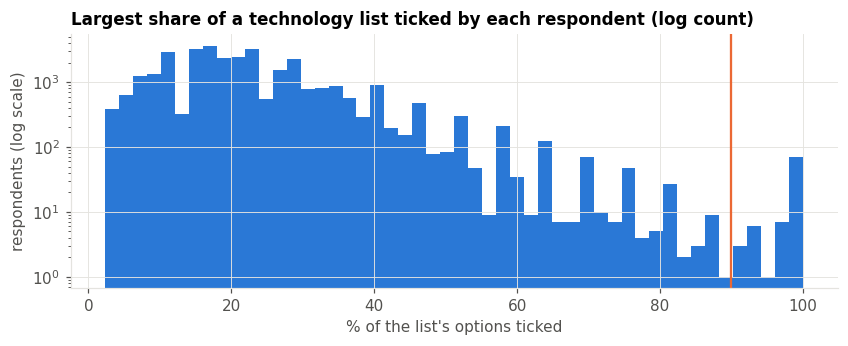

0.500     16.7
0.900     35.3
0.990     59.5
0.999    100.0

respondents ticking >= 90% of any list: 87
Language    49
Database    45
Platform    33
Webframe    28
DevEnvs     29
AIModels    28
SOTags      32


In [8]:
from skillpath.features import parse_tokens

usable_rows = raw[~near_empty]
share = pd.DataFrame({b: usable_rows[h].map(parse_tokens).map(len) / C.TECH_OPTION_COUNTS[b]
                      for b, (h, _, _) in C.TECH_BLOCKS.items()})
max_share = share.max(axis=1)
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(max_share[max_share > 0] * 100, bins=50, color=viz.BLUE, log=True)
ax.axvline(C.STRAIGHTLINE_SHARE * 100, color=viz.ORANGE, lw=1.5)
ax.set(title="Largest share of a technology list ticked by each respondent (log count)",
       xlabel="% of the list's options ticked", ylabel="respondents (log scale)")
ax.grid(axis="y")
viz.save(fig, "01_straightlining")
plt.show()
print(max_share.quantile([0.5, 0.9, 0.99, 0.999]).mul(100).round(1).rename("percentile of max share %").to_string())
flag = max_share >= C.STRAIGHTLINE_SHARE
print(f"\nrespondents ticking >= {C.STRAIGHTLINE_SHARE:.0%} of any list: {flag.sum()}")
print((share[flag] >= C.STRAIGHTLINE_SHARE).sum().rename("lists affected").to_string())

99% of people tick at most 60% of any list. Beyond that the counts fall to a
handful per bin, then jump again at exactly 100%: about 70 people ticked every
option of a list, the typical "select all" pattern of careless answering. **Decision: remove the 87 respondents who
tick 90% or more of the options in any technology list.** The threshold uses the
questionnaire's option counts, not the target, so it can run before the split.
This is the only change from the proposal's cohort figures: the recommender
cohort becomes 23,072 instead of 23,120 (48 of the 87 were in it).

## 5. Missing values follow the order of the survey

Missingness is not random. The survey is long and respondents stop at different
points (drop-out), so the further a question is from the start, the more often it
is missing. Later sections such as salary and AI agents are missing mostly because
people stopped, not because the answer is "none". This is why the cohort rules
require the technology section to be answered, and why missing technology or AI
answers are flagged as "unknown" instead of being read as "does not use".

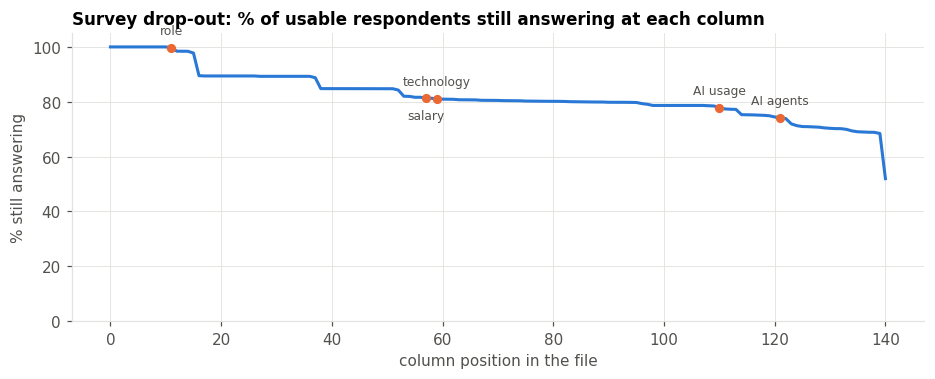

share of usable respondents who answered DevType, technology, salary, AI usage:
role          0.997
technology    0.730
salary        0.573
AI usage      0.777
AI agents     0.736


In [9]:
usable = raw[~near_empty].drop(columns=C.ID_COL)
# free-text write-ins are optional; ConvertedCompYearly and JobSat are appended at the
# end of the file by Stack Overflow, so they are left out to keep the survey order.
cols = [c for c in usable.columns if not c.endswith(("Entry", "Entr", "_TEXT", "Write"))
        and c not in ("ConvertedCompYearly", "JobSat")]
answered = usable[cols].notna().to_numpy()
# position of the last answered column = how far each respondent got
last = np.where(answered.any(axis=1), answered.shape[1] - 1 - np.argmax(answered[:, ::-1], axis=1), -1)
still = [(last >= k).mean() * 100 for k in range(len(cols))]
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(range(len(cols)), still, color=viz.BLUE, lw=2)
marks = {"DevType": "role", "LanguageHaveWorkedWith": "technology", "CompTotal": "salary",
         "AISelect": "AI usage", "AIAgents": "AI agents"}
for c, lab in marks.items():
    i = cols.index(c)
    ax.plot(i, still[i], "o", color=viz.ORANGE, ms=5)
    below = lab == "salary"  # salary sits right next to technology: label it underneath
    ax.annotate(lab, (i, still[i]), xytext=(0, -14 if below else 9), textcoords="offset points",
                fontsize=8, color=viz.TEXT2, ha="center")
ax.set(title="Survey drop-out: % of usable respondents still answering at each column",
       xlabel="column position in the file", ylabel="% still answering", ylim=(0, 105))
ax.grid(axis="y")
viz.save(fig, "01_dropout_curve")
plt.show()
print("share of usable respondents who answered DevType, technology, salary, AI usage:")
print(usable[list(marks)].notna().mean().round(3).rename(marks).to_string())

## 6. Two kinds of "missing" in the technology questions

Each technology area starts with a gate question ("Did you work with databases in
the last year or plan to?"). When the answer is **No**, the technology list is
empty *by design*: that is a real zero, not missing data. Only an empty list
after a **Yes** or an unanswered gate is truly unknown. This matters: a naive
reading would say 20% of database answers are missing, when most of those people
actually said they use no database. Among respondents who reached the technology
section, roughly three out of four empty database, platform, web framework and IDE
lists are true zeros.

In [10]:
# Only respondents who reached the technology section (answered the language gate
# or list); people who dropped out earlier are missing everything and would blur this.
reached = raw[~near_empty & (raw["LanguageChoice"].notna() | raw["LanguageHaveWorkedWith"].notna())]
print(f"respondents who reached the technology section: {len(reached):,}")
rows = []
for block, (have, want, gate) in C.TECH_BLOCKS.items():
    if gate is None:
        continue
    d = reached
    empty = d[have].isna()
    rows.append({
        "block": block,
        "list empty": int(empty.sum()),
        "of which gate = No (true zero)": int((empty & (d[gate] == "No")).sum()),
        "of which unknown": int((empty & (d[gate] != "No")).sum()),
    })
gate_tab = pd.DataFrame(rows).set_index("block")
gate_tab["true-zero share"] = (gate_tab.iloc[:, 1] / gate_tab.iloc[:, 0]).round(2)
gate_tab

respondents who reached the technology section: 32,825


,list empty,of which gate = No (true zero),of which unknown,true-zero share
block,,,,
Language,1182,660,522,0.56
Database,7325,5399,1926,0.74
Platform,8623,7059,1564,0.82
Webframe,9893,7077,2816,0.72
DevEnvs,6860,5221,1639,0.76
AIModels,16588,13295,3293,0.80


## 7. Cohort definition (record attrition)

The rules below are fixed in advance and applied in `skillpath.cohorts`. They use
no statistics learned from the data, so they are safe to apply before the
train/test split. The counts follow the approved proposal (Section 3.2) except for
the straight-lining rule added in section 4b (23,072 instead of 23,120).

In [11]:
attr = pd.read_csv(C.REPORTS_DIR / "role_cohort_attrition.csv")
attr["removed"] = (-attr["records"].diff()).fillna(0).astype(int)
attr

,step,records,removed
0,Raw public results file,49123,0
1,"Remove near-empty, duplicate and straight-lined responses",43242,5881
2,"Keep a specific developer role (drop missing DevType, Student, Retired, Other)",38036,5206
3,Keep skill-defined technical roles (drop management/seniority/non-technical),31406,6630
4,Keep respondents who answered the main technology question,23072,8334


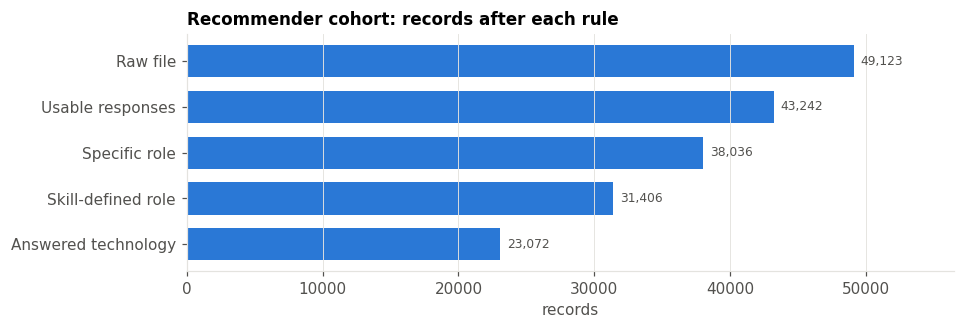

In [12]:
fig, ax = plt.subplots(figsize=(9, 2.8))
labels = ["Raw file", "Usable responses", "Specific role", "Skill-defined role", "Answered technology"]
viz.barh(ax, labels, attr["records"].tolist())
ax.set(title="Recommender cohort: records after each rule", xlabel="records")
viz.save(fig, "01_cohort_attrition")
plt.show()

### Roles excluded from the recommender

Management and seniority titles describe *level*, not a technical skill path, and
non-developer roles are outside the scenario. They stay in the salary and AI
analyses where relevant.

In [13]:
pd.Series(C.EXCLUDED_ROLES, name="reason").rename_axis("DevType").to_frame()

,reason
DevType,
Student,not a job role
Retired,not a job role
Other (please specify):,undefined role
"Architect, software or solutions","seniority level, not a skill path"
Engineering manager,"management level, not a skill path"
"Senior executive (C-suite, VP, etc.)","management level, not a skill path"
"Founder, technology or otherwise","business role, not a skill path"
Project manager,"management role, not a skill path"
Product manager,"management role, not a skill path"


## Summary

| Finding | Evidence | Consequence |
|---|---|---|
| 5,794 near-empty responses | only screening questions answered | removed |
| 1,535 redundant duplicate rows | 100% of duplicate groups are near-empty | removed by the same rule, re-checked |
| 114 more rows than published | no flag to identify them | documented, no action |
| Missingness rises through the survey | drop-out curve (section 5) | missing is not "none"; handled per block |
| Empty technology lists after gate = No | most empty lists are true zeros once drop-outs are excluded (section 6) | encode true zero vs unknown separately |
| 87 straight-lined responses | ticked 90%+ of a technology list | removed |
| Final recommender cohort | 23,072 respondents, 20 job roles, 12 families | proposal figure (23,120) minus 48 straight-liners |